In [1]:
!git clone https://github.com/applecider-ml/rtf.git

%cd rtf
# !rm -rf rtf

Cloning into 'rtf'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 106 (delta 58), reused 85 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 1.31 MiB | 17.16 MiB/s, done.
Resolving deltas: 100% (58/58), done.
/content/rtf


# MOSAIC + RTF Training Tutorial

This notebook demonstrates how to load MOSAIC parquet data, initialize a fresh RTF autoencoder, and train it from scratch on your local machine or Kaggle. It covers data preprocessing, creating a PyTorch DataLoader, and running the training loop.

In [2]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the rtf/src directory is in the Python path so we can import the model
# Adjust this path if your notebook is located elsewhere
sys.path.append(os.path.abspath('/content/rtf/src'))
from model import LightCurveCompressor

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Data Preprocessing
We use the exact same preprocessing logic as RTF to convert the raw MOSAIC format into the (Time, Band, Metadata) tensor format.

In [3]:
# The 11 metadata keys required by the 18-channel model
ALERT_META_KEYS = [
    "sharpnr", "scorr", "diffmaglim", "sky", "sigmapsf",
    "chinr", "rb", "chipsf", "distnr", "magnr", "fwhm",
]
N_BANDS = 3
MAX_LEN = 257

def load_and_preprocess_mosaic(parquet_path: str):
    print(f"Loading data from {parquet_path}...")
    df = pd.read_parquet(parquet_path)
    grouped = df.groupby("objectId")

    x_list, pad_masks, object_ids, labels = [], [], [], []

    for obj_id, group in grouped:
        group = group.sort_values("jd")
        group = group[group["fid"].isin([1, 2, 3])]  # Keep only valid ZTF bands
        if len(group) < 3: continue
        if len(group) > MAX_LEN: group = group.iloc[:MAX_LEN]

        L = len(group)
        jds = group["jd"].values.astype(np.float64)
        mags = group["magpsf"].values.astype(np.float32)
        sigs = group["sigmapsf"].values.astype(np.float32)
        fids = group["fid"].values.astype(np.int64)

        # Time Features
        dt = (jds - jds[0]).astype(np.float32)
        dt_prev = np.zeros(L, dtype=np.float32)
        dt_prev[1:] = np.diff(jds).astype(np.float32)
        log_dt, log_dt_prev = np.log1p(dt), np.log1p(dt_prev)
        logflux, logflux_err = (-0.4 * mags).astype(np.float32), (0.4 * sigs).astype(np.float32)
        base = np.column_stack([log_dt, log_dt_prev, logflux, logflux_err])

        # Band One-Hot
        one_hot = np.eye(N_BANDS, dtype=np.float32)[fids - 1]

        # Metadata (Filled with 0 if missing)
        meta = np.zeros((L, len(ALERT_META_KEYS)), dtype=np.float32)
        for j, key in enumerate(ALERT_META_KEYS):
            if key in group.columns:
                meta[:, j] = group[key].fillna(0.0).values.astype(np.float32)

        for j in range(meta.shape[1]):
            col = meta[:, j]
            med, iqr = np.median(col), np.percentile(col, 75) - np.percentile(col, 25)
            meta[:, j] = (col - med) / iqr if iqr > 1e-6 else col - med
        meta = np.clip(meta, -10.0, 10.0)

        # Combine and Pad
        x = np.concatenate([base, one_hot, meta], axis=1).astype(np.float32)
        pad_len = MAX_LEN - L
        if pad_len > 0:
            x = np.concatenate([x, np.zeros((pad_len, 18), dtype=np.float32)], axis=0)

        mask = np.zeros(MAX_LEN, dtype=bool)
        mask[L:] = True

        x_list.append(x)
        pad_masks.append(mask)
        object_ids.append(obj_id)
        labels.append(group["label_class"].iloc[0] if "label_class" in group.columns else "Unknown")

    return torch.tensor(np.stack(x_list)), torch.tensor(np.stack(pad_masks)), object_ids, labels

## 2. PyTorch Dataset
Wrap the preprocessed tensors in a standard PyTorch Dataset.

In [4]:
class MosaicDataset(Dataset):
    def __init__(self, x_tensor, pad_mask):
        self.x = x_tensor
        self.pad_mask = pad_mask

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {
            "x": self.x[idx],
            "pad_mask": self.pad_mask[idx]
        }

## 3. Training Loop
Initialize a fresh RTF model and train it using MSE reconstruction loss.

In [5]:
def train_mosaic_rtf(parquet_path: str, epochs=30, batch_size=128, lr=2e-4):
    # 1. Load Data
    x_tensor, pad_mask, _, _ = load_and_preprocess_mosaic(parquet_path)
    dataset = MosaicDataset(x_tensor, pad_mask)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    print(f"Dataset size: {len(dataset)} objects. Batches per epoch: {len(dataloader)}")

    # 2. Initialize Model (From scratch)
    model = LightCurveCompressor(
        mode="ae",          # Standard Autoencoder
        latent_dim=128,     # Size of embedding
        in_channels=18,     # 4 base + 3 bands + 11 meta
        d_model=256,
        use_images=False,
        gp_dim=0,
        num_classes=0
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr*0.01)

    # 3. Training Loop
    loss_history = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for batch_idx, batch in enumerate(dataloader):
            x = batch["x"].to(device)
            mask = batch["pad_mask"].to(device)

            optimizer.zero_grad()

            # Forward pass
            out = model(x, mask)

            # Compute loss (built-in RTF function handles masking properly)
            loss_dict = model.compute_loss(x, mask, out, beta=0.0)
            loss = loss_dict["total_loss"]

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save the trained model
    torch.save(model.state_dict(), "mosaic_rtf_model.pt")
    print("Training complete! Model saved to mosaic_rtf_model.pt")

    return model, loss_history

## 4. Run Training

In [6]:
PARQUET_FILE = "/content/train.parquet"
trained_model, losses = train_mosaic_rtf(PARQUET_FILE, epochs=30, batch_size=128, lr=2e-4)

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Loading data from /content/train.parquet...
Dataset size: 37232 objects. Batches per epoch: 291


/content/rtf/src/model.py:318: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, enc_layers)
/content/rtf/src/model.py:353: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder = nn.TransformerEncoder(dec_layer, dec_layers)


Epoch 1/30 | Avg Loss: 12.1347 | LR: 1.99e-04
Epoch 2/30 | Avg Loss: 6.2321 | LR: 1.98e-04
Epoch 3/30 | Avg Loss: 5.8168 | LR: 1.95e-04
Epoch 4/30 | Avg Loss: 5.7375 | LR: 1.91e-04
Epoch 5/30 | Avg Loss: 5.7089 | LR: 1.87e-04
Epoch 6/30 | Avg Loss: 5.6233 | LR: 1.81e-04
Epoch 7/30 | Avg Loss: 5.6383 | LR: 1.75e-04
Epoch 8/30 | Avg Loss: 5.5905 | LR: 1.67e-04
Epoch 9/30 | Avg Loss: 5.5506 | LR: 1.59e-04
Epoch 10/30 | Avg Loss: 5.5258 | LR: 1.50e-04
Epoch 11/30 | Avg Loss: 5.5082 | LR: 1.41e-04
Epoch 12/30 | Avg Loss: 5.5025 | LR: 1.32e-04
Epoch 13/30 | Avg Loss: 5.5240 | LR: 1.22e-04
Epoch 14/30 | Avg Loss: 5.5078 | LR: 1.11e-04
Epoch 15/30 | Avg Loss: 5.4651 | LR: 1.01e-04
Epoch 16/30 | Avg Loss: 5.4284 | LR: 9.07e-05
Epoch 17/30 | Avg Loss: 5.4308 | LR: 8.04e-05
Epoch 18/30 | Avg Loss: 5.4471 | LR: 7.04e-05
Epoch 19/30 | Avg Loss: 5.4059 | LR: 6.07e-05
Epoch 20/30 | Avg Loss: 5.3985 | LR: 5.15e-05


KeyboardInterrupt: 

/content/rtf/src/model.py:318: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, enc_layers)
/content/rtf/src/model.py:353: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder = nn.TransformerEncoder(dec_layer, dec_layers)


Loaded trained model weights from /content/mosaic_rtf_model.pt

Evaluating: Validation Set
Loading data from /content/val.parquet...
N objects            : 10506
Mean anomaly score   : 2.235545
Median anomaly score : 0.575413
ROC-AUC              : 0.9657
  TPR ≥ 90% → FPR = 0.0296  (thr = 1.320345)
  TPR ≥ 95% → FPR = 0.0305  (thr = 1.144925)


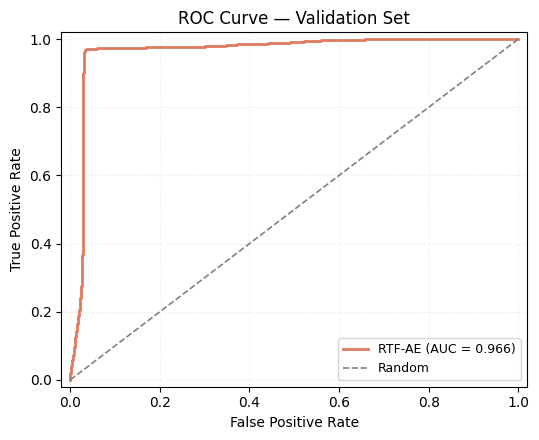


Evaluating: Test Set
Loading data from /content/test.parquet...
N objects            : 12761
Mean anomaly score   : 1.986075
Median anomaly score : 0.563803
ROC-AUC              : 0.9678
  TPR ≥ 90% → FPR = 0.0285  (thr = 1.458673)
  TPR ≥ 95% → FPR = 0.0297  (thr = 1.096972)


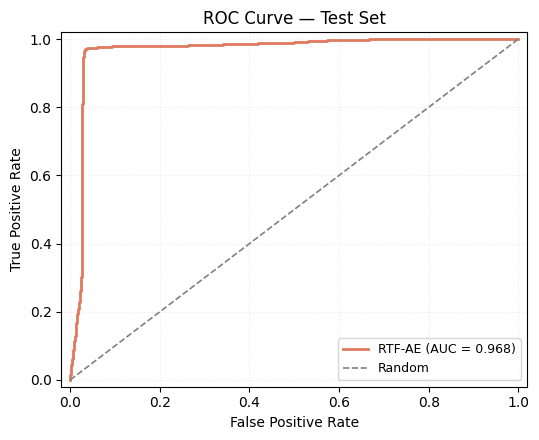

In [7]:
import sys
import os
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from collections import Counter

sys.path.append('/content/rtf/src')
from model import LightCurveCompressor

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH   = "/content/mosaic_rtf_model.pt"
VAL_PARQUET  = "/content/val.parquet"
TEST_PARQUET = "/content/test.parquet"

# Metadata & Constants per RTF spec
ALERT_META_KEYS = [
    "sharpnr", "scorr", "diffmaglim", "sky", "sigmapsf",
    "chinr", "rb", "chipsf", "distnr", "magnr", "fwhm",
]
N_BANDS = 3
MAX_LEN = 257

# ------------------------------------------
# Official RTF Data Preprocessing (Updated for subclasses)
# ------------------------------------------
def load_and_preprocess_mosaic(parquet_path: str):
    print(f"Loading data from {parquet_path}...")
    df = pd.read_parquet(parquet_path)
    grouped = df.groupby("objectId")

    x_list, pad_masks, object_ids, labels, subclasses = [], [], [], [], []

    for obj_id, group in grouped:
        group = group.sort_values("jd")
        group = group[group["fid"].isin([1, 2, 3])]  # Keep only valid ZTF bands
        if len(group) < 3:
            continue
        if len(group) > MAX_LEN:
            group = group.iloc[:MAX_LEN]

        L = len(group)
        jds = group["jd"].values.astype(np.float64)
        mags = group["magpsf"].values.astype(np.float32)
        sigs = group["sigmapsf"].values.astype(np.float32)
        fids = group["fid"].values.astype(np.int64)

        # Time Features
        dt = (jds - jds[0]).astype(np.float32)
        dt_prev = np.zeros(L, dtype=np.float32)
        dt_prev[1:] = np.diff(jds).astype(np.float32)
        log_dt, log_dt_prev = np.log1p(dt), np.log1p(dt_prev)
        logflux, logflux_err = (-0.4 * mags).astype(np.float32), (0.4 * sigs).astype(np.float32)
        base = np.column_stack([log_dt, log_dt_prev, logflux, logflux_err])

        # Band One-Hot
        one_hot = np.eye(N_BANDS, dtype=np.float32)[fids - 1]

        # Metadata (Filled with 0 if missing)
        meta = np.zeros((L, len(ALERT_META_KEYS)), dtype=np.float32)
        for j, key in enumerate(ALERT_META_KEYS):
            if key in group.columns:
                meta[:, j] = group[key].fillna(0.0).values.astype(np.float32)

        for j in range(meta.shape[1]):
            col = meta[:, j]
            med, iqr = np.median(col), np.percentile(col, 75) - np.percentile(col, 25)
            meta[:, j] = (col - med) / iqr if iqr > 1e-6 else col - med
        meta = np.clip(meta, -10.0, 10.0)

        # Combine and Pad
        x = np.concatenate([base, one_hot, meta], axis=1).astype(np.float32)
        pad_len = MAX_LEN - L
        if pad_len > 0:
            x = np.concatenate([x, np.zeros((pad_len, 18), dtype=np.float32)], axis=0)

        mask = np.zeros(MAX_LEN, dtype=bool)
        mask[L:] = True

        x_list.append(x)
        pad_masks.append(mask)
        object_ids.append(obj_id)
        labels.append(group["label_class"].iloc[0] if "label_class" in group.columns else 0)
        subclasses.append(group["subclass"].iloc[0] if "subclass" in group.columns else "Unknown")

    return torch.tensor(np.stack(x_list)), torch.tensor(np.stack(pad_masks)), object_ids, labels, subclasses

# ------------------------------------------
# Dataset Wrapper
# ------------------------------------------
class MosaicDataset(Dataset):
    def __init__(self, x_tensor, pad_mask):
        self.x = x_tensor
        self.pad_mask = pad_mask

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {
            "x": self.x[idx],
            "pad_mask": self.pad_mask[idx]
        }

# ------------------------------------------
# Load model exactly as trained
# ------------------------------------------
model = LightCurveCompressor(
    mode="ae",
    latent_dim=128,
    in_channels=18,
    d_model=256,
    use_images=False,
    gp_dim=0,
    num_classes=0
).to(device)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f"Loaded trained model weights from {MODEL_PATH}")

# ------------------------------------------
# RTF Anomaly Scoring
# ------------------------------------------
def compute_per_object_loss(model, dataloader):
    scores = []
    with torch.no_grad():
        for batch in dataloader:
            x = batch["x"].to(device)
            mask = batch["pad_mask"].to(device)
            # Official RTF reconstruction error
            scores.extend(model.reconstruction_error(x, mask).cpu().numpy())
    return np.array(scores)

def evaluate_dataset(parquet_path: str, dataset_name: str):
    print(f"\n{'='*50}")
    print(f"Evaluating: {dataset_name}")
    print(f"{'='*50}")

    x_tensor, pad_mask, object_ids, labels, subclasses = load_and_preprocess_mosaic(parquet_path)

    dataset = MosaicDataset(x_tensor, pad_mask)
    dataloader = DataLoader(dataset, batch_size=128, shuffle=False)

    scores = compute_per_object_loss(model, dataloader)

    labels = np.array(labels)
    subclasses = np.array(subclasses)
    object_ids = np.array(object_ids)

    print(f"N objects            : {len(scores)}")
    print(f"Mean anomaly score   : {np.mean(scores):.6f}")
    print(f"Median anomaly score : {np.median(scores):.6f}")

    y_true = (labels == 1).astype(int)

    fpr = tpr = thresholds = roc_auc = None

    if len(np.unique(y_true)) > 1:
        fpr, tpr, thresholds = roc_curve(y_true, scores)
        roc_auc = auc(fpr, tpr)
        print(f"ROC-AUC              : {roc_auc:.4f}")

        for target in [0.90, 0.95]:
            idxs = np.where(tpr >= target)[0]
            if len(idxs):
                i = idxs[0]
                print(f"  TPR ≥ {target:.0%} → FPR = {fpr[i]:.4f}  (thr = {thresholds[i]:.6f})")

        plt.figure(figsize=(5.5, 4.5))
        plt.plot(fpr, tpr, color="#E07A5F", lw=2, label=f"RTF-AE (AUC = {roc_auc:.3f})")
        plt.plot([0, 1], [0, 1], color="gray", lw=1.2, linestyle="--", label="Random")
        plt.xlim([-0.02, 1.02]); plt.ylim([-0.02, 1.02])
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve — {dataset_name}")
        plt.legend(loc="lower right", fontsize=9)
        plt.grid(True, alpha=0.25, linestyle=":")
        plt.tight_layout()
        plt.savefig(f"roc_{dataset_name.lower().replace(' ', '_')}.png", dpi=200, bbox_inches="tight")
        plt.show()
    else:
        print("Only one class present → skipping ROC")

    score_df = pd.DataFrame({'object_id': object_ids, 'rtf_score': scores})
    score_df.to_csv(f"{dataset_name.lower().replace(' ', '_')}_rtf_scores.csv", index=False)

    return {
        "scores": scores,
        "labels": labels,
        "subclasses": subclasses,
        "object_ids": object_ids,
        "y_true": y_true,
        "fpr": fpr, "tpr": tpr, "thresholds": thresholds,
        "roc_auc": roc_auc,
        "name": dataset_name,
    }

# Run evaluation
val_results  = evaluate_dataset(VAL_PARQUET,  "Validation Set")
test_results = evaluate_dataset(TEST_PARQUET, "Test Set")

Using threshold for TPR ≥ 95%: 1.096972
Achieved TPR / FPR : 0.950 / 0.030

False Positives (impostors called KN): 339
False Negatives (missed KN)          : 67

=== False Positives by subclass ===
  SNIbc                :   305
  SNIa                 :    16
  AGN                  :     8
  SNII                 :     5
  Blazar               :     2
  QSO                  :     2
  RRL                  :     1

=== False Negatives by subclass ===
  Kilonovae            :    67


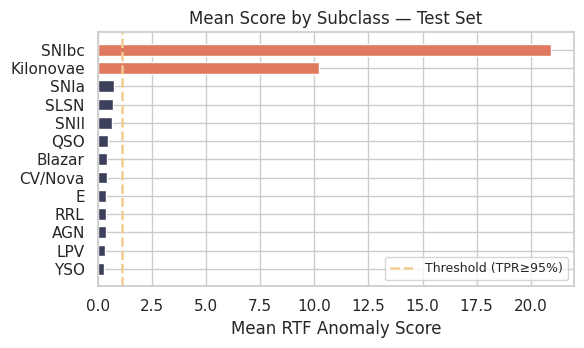

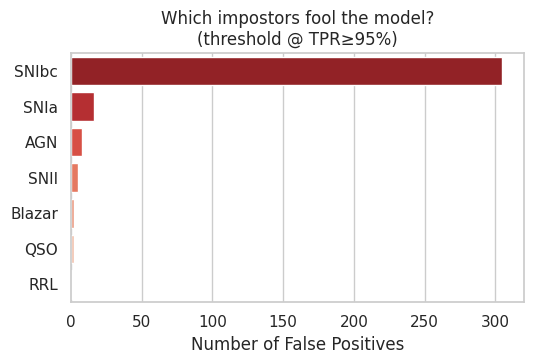

In [ ]:
# ==========================================
# POST-HOC ANALYSIS (does NOT affect the model or the scores)
# ==========================================
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)

def analyze_false_positives(results, target_tpr=0.95, save_prefix="test"):
    """
    Uses the already-computed RTF scores.
    Only looks at subclass to answer:
    "Which impostor types are fooling the model the most?"
    """
    scores     = results["scores"]
    subclasses = results["subclasses"]
    y_true     = results["y_true"]
    fpr, tpr, thresholds = results["fpr"], results["tpr"], results["thresholds"]
    name       = results["name"]

    if fpr is None:
        print("No ROC available.")
        return

    # Same threshold that was used for the reported TPR/FPR
    idxs = np.where(tpr >= target_tpr)[0]
    thr = thresholds[idxs[0]]
    print(f"Using threshold for TPR ≥ {target_tpr:.0%}: {thr:.6f}")
    print(f"Achieved TPR / FPR : {tpr[idxs[0]]:.3f} / {fpr[idxs[0]]:.3f}")

    y_pred = (scores >= thr).astype(int)

    fp_mask = (y_pred == 1) & (y_true == 0)   # predicted KN, actually impostor
    fn_mask = (y_pred == 0) & (y_true == 1)   # missed real KN

    print(f"\nFalse Positives (impostors called KN): {fp_mask.sum()}")
    print(f"False Negatives (missed KN)          : {fn_mask.sum()}")

    # ----- The table the email asked for -----
    print("\n=== False Positives by subclass ===")
    fp_counts = Counter(subclasses[fp_mask])
    for cls, cnt in fp_counts.most_common():
        print(f"  {cls:20s} : {cnt:5d}")

    print("\n=== False Negatives by subclass ===")
    fn_counts = Counter(subclasses[fn_mask])
    for cls, cnt in fn_counts.most_common():
        print(f"  {cls:20s} : {cnt:5d}")

    # Mean score per subclass (interpretation only)
    df = pd.DataFrame({"subclass": subclasses, "score": scores})
    class_stats = (
        df.groupby("subclass")["score"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(6, max(3.2, 0.28 * len(class_stats))))
    colors = ["#E07A5F" if m > thr else "#3D405B" for m in class_stats["mean"]]
    ax.barh(class_stats.index.astype(str), class_stats["mean"], color=colors, height=0.65)
    ax.axvline(thr, color="#F2CC8F", lw=1.8, linestyle="--", label=f"Threshold (TPR≥{target_tpr:.0%})")
    ax.set_xlabel("Mean RTF Anomaly Score")
    ax.set_title(f"Mean Score by Subclass — {name}")
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_mean_score_per_subclass.png", dpi=200, bbox_inches="tight")
    plt.show()

    # FP composition plot
    if len(fp_counts) > 0:
        fp_df = pd.DataFrame(fp_counts.most_common(), columns=["subclass", "count"])
        fig, ax = plt.subplots(figsize=(5.5, 3.8))
        sns.barplot(data=fp_df, y="subclass", x="count", hue="subclass", palette="Reds_r", legend=False, ax=ax)
        ax.set_xlabel("Number of False Positives")
        ax.set_ylabel("")
        ax.set_title(f"Which impostors fool the model?\n(threshold @ TPR≥{target_tpr:.0%})")
        plt.tight_layout()
        plt.savefig(f"{save_prefix}_false_positives_by_subclass.png", dpi=200, bbox_inches="tight")
        plt.show()

    return {"threshold": thr, "fp_counts": fp_counts, "fn_counts": fn_counts, "class_stats": class_stats}

# Interpretation only — does not change any scores
analysis = analyze_false_positives(test_results, target_tpr=0.95, save_prefix="test")